In [1]:
%load_ext rpy2.ipython

In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.cm as cm
from matplotlib import colormaps
from matplotlib import colors
from sklearn.decomposition import PCA
import tools
import importlib
importlib.reload(tools)

<module 'tools' from '/home/eliska/evolution/code/tools.py'>

In [8]:
morphotopes = gpd.read_parquet('/data/uscuni-evolution/all_joined_fr.parquet')
morphotopes

,geometry,initially_noise,level_1_label,level_2_label,level_3_label,level_4_label,level_5_label,level_6_label,level_7_label,num_buildings,...,mibElo,mibERI,mibCCo,mibLAL,mibFR,mibSCo,micBAD,midBAD,limLPS,limAre
morphotope_id,,,,,,,,,,,,,,,,,,,,,
483878_11_5,"MULTIPOLYGON (((3892732.777 2269790.62, 389273...",False,1,1,1,1,2,4,6,83,...,0.507157,0.901393,0.431894,28.997739,3.457417,3.457417,88.634839,94.169161,1.0,9739.330948
483878_11_7,"MULTIPOLYGON (((3893221.499 2270654.857, 38932...",False,2,4,7,12,18,41,76,49,...,0.393028,0.826700,0.294159,34.920752,2.997175,2.997175,37.757262,55.333813,1.0,4035.617791
483878_11_8,"MULTIPOLYGON (((3893095.385 2270658.299, 38930...",False,2,4,7,12,18,41,76,129,...,0.624465,0.754920,0.463325,21.349775,2.450073,2.450073,31.918897,39.710241,1.0,4982.620881
483878_11_1,"MULTIPOLYGON (((3893363.223 2271108.051, 38933...",False,1,1,2,3,4,8,15,53,...,0.664117,0.998579,0.535040,18.377784,2.623197,2.623197,58.638190,312.830201,0.0,22181.556838
483878_11_3,"MULTIPOLYGON (((3893704.281 2271201.893, 38937...",False,2,4,8,17,24,55,103,96,...,0.102283,0.994327,0.126292,101.673796,4.572050,4.572050,26.219521,16.150865,1.0,6452.503903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532006_120_4,"MULTIPOLYGON (((4135500.135 2751944.602, 41355...",False,2,4,7,15,22,52,95,52,...,0.769024,0.964250,0.576369,18.267817,2.830500,2.830500,95.571667,96.368180,1.0,6631.608607
532006_120_6,"MULTIPOLYGON (((4135409.842 2751890.38, 413540...",False,2,4,7,13,20,47,87,106,...,0.621641,0.917922,0.479623,19.655636,2.725132,2.725132,58.517959,66.234961,1.0,7181.585813
532006_120_5,"MULTIPOLYGON (((4135409.804 2751572.052, 41354...",False,2,4,8,17,26,57,109,48,...,0.750954,0.743220,0.354245,33.462678,2.783624,2.783624,74.300931,61.037182,1.0,6009.680646


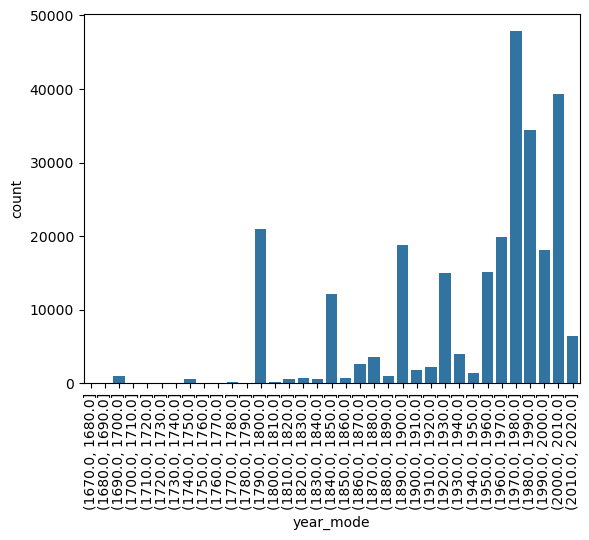

In [9]:
sns.countplot(x='year_mode', data=morphotopes, order=sorted(morphotopes["year_mode"].unique())  # alphabetical order
)

# Rotate x-axis labels vertically
_ = plt.xticks(rotation=90)

In [10]:
pivot3 = tools.pivot_tbl(morphotopes, 3)
pivot3

level_3_label,1,2,3,4,5,6,7,8
year_mode,,,,,,,,
"(1670.0, 1680.0]",0.000000,0.000000,0.000000,0.113573,0.191136,0.307479,0.000000,0.387812
"(1680.0, 1690.0]",0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
"(1690.0, 1700.0]",0.007755,0.005315,0.028074,0.081709,0.145703,0.220091,0.162732,0.348621
"(1700.0, 1710.0]",0.000000,0.000000,0.005952,0.047619,0.000000,0.000000,0.607143,0.339286
"(1710.0, 1720.0]",0.034063,0.000000,0.043796,0.069343,0.201946,0.000000,0.273723,0.377129
"(1720.0, 1730.0]",0.000000,0.000000,0.000000,0.194030,0.326493,0.166045,0.059701,0.253731
"(1730.0, 1740.0]",0.000000,0.033898,0.000000,0.316384,0.118644,0.000000,0.431262,0.099812
"(1740.0, 1750.0]",0.008266,0.004557,0.033065,0.139710,0.159731,0.178464,0.172240,0.303967
"(1750.0, 1760.0]",0.049428,0.000000,0.037461,0.134755,0.089490,0.193028,0.053070,0.442768


In [11]:
nuts = gpd.read_file(
    "https://gisco-services.ec.europa.eu/distribution/v2/nuts/gpkg/NUTS_RG_01M_2024_3035.gpkg"
)

In [12]:
nuts1 = nuts[(nuts["CNTR_CODE"]=='FR') & (nuts["LEVL_CODE"]==1)]
nuts1

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
1677,FRC,1,FR,Bourgogne-Franche-Comté,Bourgogne-Franche-Comté,NaN,NaN,NaN,"POLYGON ((3832219.92 2830992.502, 3832953.317 ..."
1678,FRK,1,FR,Auvergne-Rhône-Alpes,Auvergne-Rhône-Alpes,NaN,NaN,NaN,"POLYGON ((3785951.88 2657239.289, 3786591.606 ..."
1679,FRF,1,FR,Grand Est,Grand Est,NaN,NaN,NaN,"MULTIPOLYGON (((3954303.652 3011643.819, 39541..."
1680,FRH,1,FR,Bretagne,Bretagne,NaN,NaN,NaN,"MULTIPOLYGON (((3356536.086 2945175.602, 33562..."
1681,FRI,1,FR,Nouvelle-Aquitaine,Nouvelle-Aquitaine,NaN,NaN,NaN,"MULTIPOLYGON (((3566670.039 2724045.961, 35674..."
1682,FRL,1,FR,Provence-Alpes-Côte d’Azur,Provence-Alpes-Côte d’Azur,NaN,NaN,NaN,"MULTIPOLYGON (((4026458.121 2453484.845, 40275..."
1683,FRG,1,FR,Pays de la Loire,Pays de la Loire,NaN,NaN,NaN,"MULTIPOLYGON (((3568903.123 2879717.979, 35689..."
1684,FRM,1,FR,Corse,Corse,NaN,NaN,NaN,"MULTIPOLYGON (((4274214.75 2211483.05, 4274524..."
1685,FR1,1,FR,Ile-de-France,Ile-de-France,NaN,NaN,NaN,"POLYGON ((3720530.95 2929882.842, 3721184.339 ..."
1686,FRJ,1,FR,Occitanie,Occitanie,NaN,NaN,NaN,"MULTIPOLYGON (((3655119.419 2473263.864, 36553..."


In [13]:
morphotopes_centr = morphotopes.copy()
morphotopes_centr["geometry"] = morphotopes_centr.geometry.centroid
morphotopes_centr.columns

Index(['geometry', 'initially_noise', 'level_1_label', 'level_2_label',
       'level_3_label', 'level_4_label', 'level_5_label', 'level_6_label',
       'level_7_label', 'num_buildings', 'year_mean', 'year_median',
       'year_min', 'year_q10', 'year_q90', 'year_max', 'year_std', 'year_mode',
       'sdbAre', 'sdbPer', 'sdbCoA', 'ssbCCo', 'ssbSqu', 'ssbERI', 'ssbElo',
       'libNCo', 'ldbPWL', 'ltcBuA', 'mtbAli', 'mtbNDi', 'ltbIBD', 'stbSAl',
       'sdsLen', 'sssLin', 'ldsMSL', 'ldsRea', 'ldsAre', 'sisBpM', 'sdsSPW',
       'sdsSPO', 'sdsSWD', 'lcdMes', 'linP3W', 'linP4W', 'linPDE', 'lcnClo',
       'lddNDe', 'linWID', 'ldsCDL', 'xcnSCl', 'mtdMDi', 'sddAre', 'midRea',
       'midAre', 'sdcLAL', 'sdcAre', 'sscCCo', 'sscERI', 'mtcWNe', 'mdcAre',
       'ltcWRB', 'sicCAR', 'sdsAre', 'mibCou', 'mibAre', 'mibLen', 'mibElo',
       'mibERI', 'mibCCo', 'mibLAL', 'mibFR', 'mibSCo', 'micBAD', 'midBAD',
       'limLPS', 'limAre'],
      dtype='object')

In [14]:
joined = morphotopes_centr.sjoin(nuts1, predicate="within")

In [15]:
joined

,geometry,initially_noise,level_1_label,level_2_label,level_3_label,level_4_label,level_5_label,level_6_label,level_7_label,num_buildings,...,limAre,index_right,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
morphotope_id,,,,,,,,,,,,,,,,,,,,,
483878_11_5,POINT (3892944.475 2270313.217),False,1,1,1,1,2,4,6,83,...,9739.330948,1682,FRL,1,FR,Provence-Alpes-Côte d’Azur,Provence-Alpes-Côte d’Azur,NaN,NaN,NaN
483878_11_7,POINT (3893311.226 2270673.758),False,2,4,7,12,18,41,76,49,...,4035.617791,1682,FRL,1,FR,Provence-Alpes-Côte d’Azur,Provence-Alpes-Côte d’Azur,NaN,NaN,NaN
483878_11_8,POINT (3893184.881 2270840.534),False,2,4,7,12,18,41,76,129,...,4982.620881,1682,FRL,1,FR,Provence-Alpes-Côte d’Azur,Provence-Alpes-Côte d’Azur,NaN,NaN,NaN
483878_11_1,POINT (3893842.535 2271714.183),False,1,1,2,3,4,8,15,53,...,22181.556838,1682,FRL,1,FR,Provence-Alpes-Côte d’Azur,Provence-Alpes-Côte d’Azur,NaN,NaN,NaN
483878_11_3,POINT (3893896.544 2271293.969),False,2,4,8,17,24,55,103,96,...,6452.503903,1682,FRL,1,FR,Provence-Alpes-Côte d’Azur,Provence-Alpes-Côte d’Azur,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532006_120_4,POINT (4135833.821 2752118.152),False,2,4,7,15,22,52,95,52,...,6631.608607,1679,FRF,1,FR,Grand Est,Grand Est,NaN,NaN,NaN
532006_120_6,POINT (4135608.39 2751851.083),False,2,4,7,13,20,47,87,106,...,7181.585813,1679,FRF,1,FR,Grand Est,Grand Est,NaN,NaN,NaN
532006_120_5,POINT (4135541.929 2751669.91),False,2,4,8,17,26,57,109,48,...,6009.680646,1679,FRF,1,FR,Grand Est,Grand Est,NaN,NaN,NaN


In [16]:
nuts_counts = (
    joined.pivot_table(
        index=["NUTS_NAME", "year_mode"],
        columns="level_3_label",
        values="num_buildings",
        aggfunc="sum",
        fill_value=0
    )
)
nuts_counts

level_3_label                                    1     2     3      4      5  \
NUTS_NAME                  year_mode                                           
Auvergne-Rhône-Alpes       (1690.0, 1700.0]     79    11    26    368    640   
                           (1710.0, 1720.0]      0     0     0      0      0   
                           (1730.0, 1740.0]      0     0     0     51      0   
                           (1740.0, 1750.0]     28     0     0    222    319   
                           (1750.0, 1760.0]      0     0     0     45     37   
...                                            ...   ...   ...    ...    ...   
Provence-Alpes-Côte d’Azur (1970.0, 1980.0]   7298  1749  6159  52344  51408   
                           (1980.0, 1990.0]   6126  3216  8467  43408  60089   
                           (1990.0, 2000.0]   3872  1834  4305  19593  34797   
                           (2000.0, 2010.0]  10522  4051  4443  32903  48890   
                           (2010.0, 2020.0]   1611   729   470   4107   9402   

level_3_label                                   6      7      8  
NUTS_NAME                  year_mode                             
Auvergne-Rhône-Alpes       (1690.0, 1700.0]  1168    591   1165  
                           (1710.0, 1720.0]     0     37      0  
                           (1730.0, 1740.0]     0      0      0  
                           (1740.0, 1750.0]   295    315    557  
                           (1750.0, 1760.0]    55     70    170  
...                                           ...    ...    ...  
Provence-Alpes-Côte d’Azur (1970.0, 1980.0]   396  63254  22521  
                           (1980.0, 1990.0]    52  86800  26760  
                           (1990.0, 2000.0]   333  43600  13569  
                           (2000.0, 2010.0]   127  31440  12393  
                           (2010.0, 2020.0]     0   4007   1997  

[400 rows x 8 columns]

In [17]:
nuts_counts = nuts_counts.reset_index()
nuts_counts

level_3_label,NUTS_NAME,year_mode,1,2,3,4,5,6,7,8
0,Auvergne-Rhône-Alpes,"(1690.0, 1700.0]",79,11,26,368,640,1168,591,1165
1,Auvergne-Rhône-Alpes,"(1710.0, 1720.0]",0,0,0,0,0,0,37,0
2,Auvergne-Rhône-Alpes,"(1730.0, 1740.0]",0,0,0,51,0,0,0,0
3,Auvergne-Rhône-Alpes,"(1740.0, 1750.0]",28,0,0,222,319,295,315,557
4,Auvergne-Rhône-Alpes,"(1750.0, 1760.0]",0,0,0,45,37,55,70,170
...,...,...,...,...,...,...,...,...,...,...
395,Provence-Alpes-Côte d’Azur,"(1970.0, 1980.0]",7298,1749,6159,52344,51408,396,63254,22521
396,Provence-Alpes-Côte d’Azur,"(1980.0, 1990.0]",6126,3216,8467,43408,60089,52,86800,26760
397,Provence-Alpes-Côte d’Azur,"(1990.0, 2000.0]",3872,1834,4305,19593,34797,333,43600,13569
398,Provence-Alpes-Côte d’Azur,"(2000.0, 2010.0]",10522,4051,4443,32903,48890,127,31440,12393


In [18]:
agg_cols = [i for i in range(1, 9)]

nuts_counts['total_count'] = nuts_counts[agg_cols].sum(axis=1)
for col in agg_cols:
    nuts_counts[f'{col}_pct'] = nuts_counts[col] / nuts_counts['total_count']

nuts_counts

level_3_label,NUTS_NAME,year_mode,1,2,3,4,5,6,7,8,total_count,1_pct,2_pct,3_pct,4_pct,5_pct,6_pct,7_pct,8_pct
0,Auvergne-Rhône-Alpes,"(1690.0, 1700.0]",79,11,26,368,640,1168,591,1165,4048,0.019516,0.002717,0.006423,0.090909,0.158103,0.288538,0.145998,0.287796
1,Auvergne-Rhône-Alpes,"(1710.0, 1720.0]",0,0,0,0,0,0,37,0,37,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
2,Auvergne-Rhône-Alpes,"(1730.0, 1740.0]",0,0,0,51,0,0,0,0,51,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
3,Auvergne-Rhône-Alpes,"(1740.0, 1750.0]",28,0,0,222,319,295,315,557,1736,0.016129,0.000000,0.000000,0.127880,0.183756,0.169931,0.181452,0.320853
4,Auvergne-Rhône-Alpes,"(1750.0, 1760.0]",0,0,0,45,37,55,70,170,377,0.000000,0.000000,0.000000,0.119363,0.098143,0.145889,0.185676,0.450928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,Provence-Alpes-Côte d’Azur,"(1970.0, 1980.0]",7298,1749,6159,52344,51408,396,63254,22521,205129,0.035578,0.008526,0.030025,0.255176,0.250613,0.001930,0.308362,0.109789
396,Provence-Alpes-Côte d’Azur,"(1980.0, 1990.0]",6126,3216,8467,43408,60089,52,86800,26760,234918,0.026077,0.013690,0.036042,0.184779,0.255787,0.000221,0.369491,0.113912
397,Provence-Alpes-Côte d’Azur,"(1990.0, 2000.0]",3872,1834,4305,19593,34797,333,43600,13569,121903,0.031763,0.015045,0.035315,0.160726,0.285448,0.002732,0.357661,0.111310
398,Provence-Alpes-Côte d’Azur,"(2000.0, 2010.0]",10522,4051,4443,32903,48890,127,31440,12393,144769,0.072681,0.027983,0.030690,0.227279,0.337710,0.000877,0.217174,0.085605


In [21]:
import re

# 1. Load data
df_plot = nuts_counts.copy()

# 2. Fix the 'year' column
def clean_year(val):
    # Handle simple floats or the interval string
    if isinstance(val, (int, float)):
        return int(val)
    match = re.search(r'\((\d+)\.', str(val))
    return int(match.group(1)) if match else None

df_plot['year'] = df_plot['year_mode'].apply(clean_year)
df_plot = df_plot[df_plot['year'] >= 1850].copy()

# 3. ROBUST RENAMING (The Fix)
# We ensure column names '1', '2', etc. are treated as integers to match your dataframe
class_map = {
    1: 'Incoherent Large-Scale Homogeneous',
    2: 'Incoherent Large-Scale Heterogeneous',
    3: 'Incoherent Small-Scale Linear',
    4: 'Incoherent Small-Scale Sparse',
    5: 'Incoherent Small-Scale Compact',
    6: 'Coherent Interconnected',
    7: 'Coherent Dense Disjoint',
    8: 'Coherent Dense Adjacent'
}

# Ensure the DataFrame columns are actually integers so the map works
# (If they are strings '1', this will fail, so we try both)
try:
    df_plot.rename(columns=class_map, inplace=True)
except:
    # Fallback: if columns are strings '1', '2', change map to strings
    str_map = {str(k): v for k, v in class_map.items()}
    df_plot.rename(columns=str_map, inplace=True)

# 4. Melt
value_vars = list(class_map.values())

# DEBUG: Check if columns exist now
missing_cols = [c for c in value_vars if c not in df_plot.columns]
if missing_cols:
    print("STILL MISSING:", missing_cols)
    print("ACTUAL COLUMNS:", df_plot.columns.tolist())
else:
    df_long = df_plot.melt(id_vars=['NUTS_NAME', 'year'], 
                           value_vars=value_vars, 
                           var_name='class_name', 
                           value_name='count')

    # 5. Normalize
    df_long['pct'] = df_long.groupby(['NUTS_NAME', 'year'])['count'].transform(lambda x: x / x.sum())
    
df_long

,NUTS_NAME,year,class_name,count,pct
0,Auvergne-Rhône-Alpes,1850,Incoherent Large-Scale Homogeneous,18,0.005318
1,Auvergne-Rhône-Alpes,1860,Incoherent Large-Scale Homogeneous,87,0.008104
2,Auvergne-Rhône-Alpes,1870,Incoherent Large-Scale Homogeneous,121,0.007421
3,Auvergne-Rhône-Alpes,1880,Incoherent Large-Scale Homogeneous,34,0.006392
4,Auvergne-Rhône-Alpes,1890,Incoherent Large-Scale Homogeneous,2220,0.014847
...,...,...,...,...,...
1747,Provence-Alpes-Côte d’Azur,1970,Coherent Dense Adjacent,22521,0.109789
1748,Provence-Alpes-Côte d’Azur,1980,Coherent Dense Adjacent,26760,0.113912
1749,Provence-Alpes-Côte d’Azur,1990,Coherent Dense Adjacent,13569,0.111310
1750,Provence-Alpes-Côte d’Azur,2000,Coherent Dense Adjacent,12393,0.085605


In addition: Warning messages:
1: st_centroid assumes attributes are constant over geometries 
2: st_centroid assumes attributes are constant over geometries 
3: st_centroid assumes attributes are constant over geometries 
4: st_centroid assumes attributes are constant over geometries 


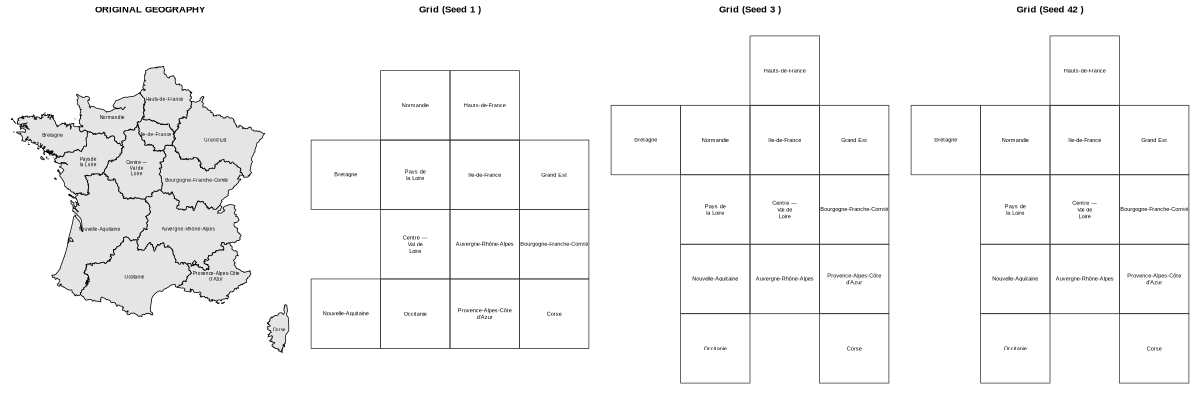

In [22]:
%%R -w 1200 -h 400

library(sf)
library(dplyr)
library(geogrid)

# 1. GET DATA
url <- "https://gisco-services.ec.europa.eu/distribution/v2/nuts/gpkg/NUTS_RG_01M_2024_3035.gpkg"
nuts1_fr <- read_sf(url) %>%
  filter(CNTR_CODE == "FR", LEVL_CODE == 1, NUTS_ID != "FRY")

# Helper to wrap text
wrap_text <- function(x) {
  sapply(x, function(y) paste(strwrap(y, width = 10), collapse = "\n"))
}

# 2. SETUP PLOT (1 row, 4 columns)
# Col 1 = Real Map, Cols 2-4 = Grids
par(mfrow=c(1, 4), mar=c(0,0,2,0))

# --- PLOT 1: ORIGINAL MAP ---
plot(st_geometry(nuts1_fr), main = "ORIGINAL GEOGRAPHY", col="grey90")
# Add text labels to original map
text(st_coordinates(st_centroid(nuts1_fr)), 
     labels = wrap_text(nuts1_fr$NUTS_NAME), 
     cex = 0.6, col="black")

# --- PLOT 2-4: GRIDS (Seeds 1, 3, 42) ---
for (seed_val in c(1, 3, 42)) {
  
  # Calculate grid
  new_grid <- calculate_grid(shape = nuts1_fr, grid_type = "regular", seed = seed_val)
  grid_shapes <- assign_polygons(nuts1_fr, new_grid)
  
  # Plot grid
  plot(st_geometry(grid_shapes), main = paste("Grid (Seed", seed_val, ")"), border="grey20")
  text(st_coordinates(st_centroid(grid_shapes)), 
       labels = wrap_text(grid_shapes$NUTS_NAME), 
       cex = 0.7)
}

Note: You provided a user-specified grid. If this is a generally-useful
  grid, please consider submitting it to become a part of the geofacet
  package. You can do this easily by calling:
  grid_submit(__grid_df_name__)
In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


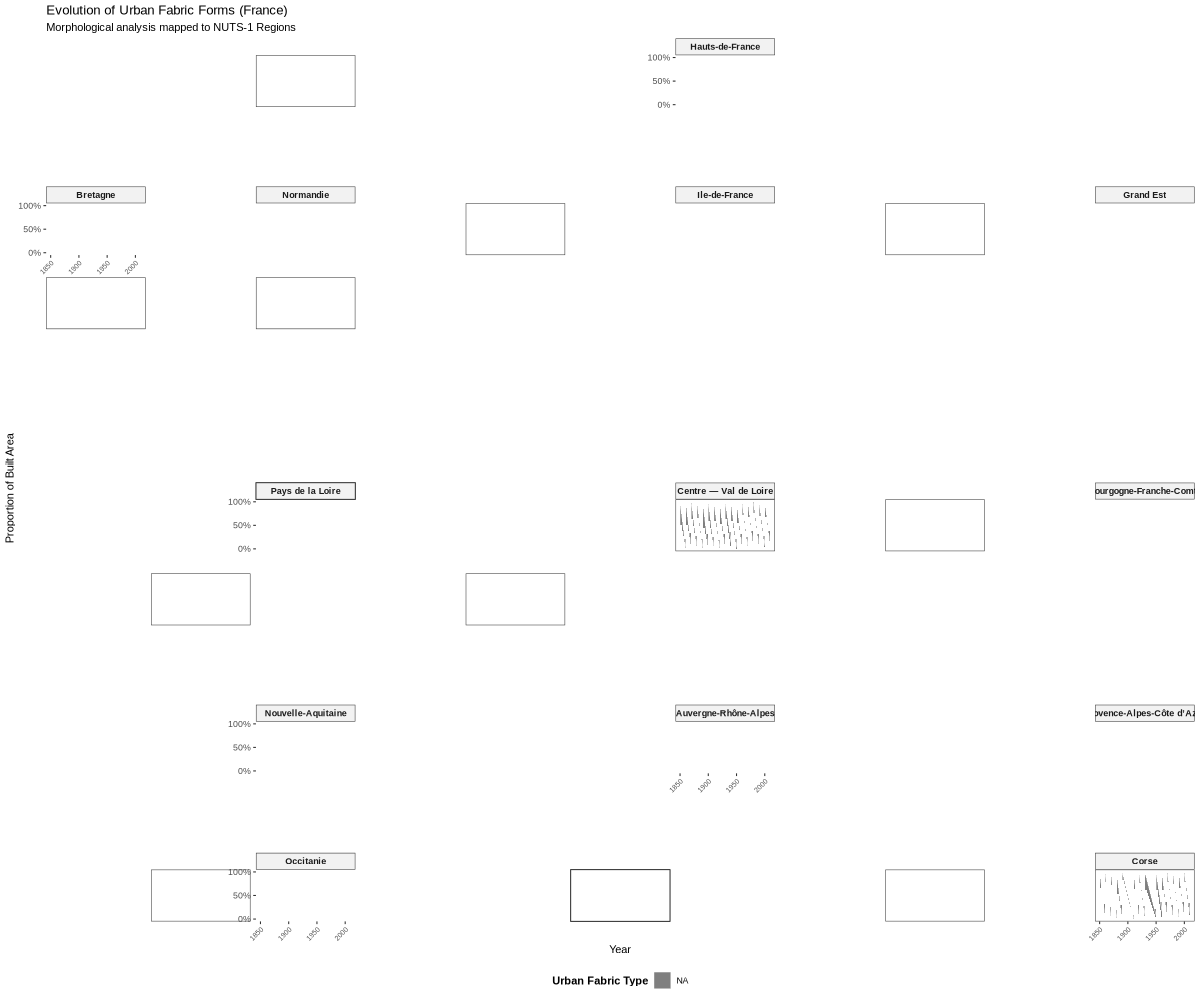

In [23]:
%%R -i df_long -w 1200 -h 1000

library(ggplot2)
library(geofacet)
library(dplyr)

# --- 1. DEFINE COLORS & ORDER ---

# A. Custom Hex Colors to match your image
fabric_colors <- c(
  "Incoherent Large-Scale Homogeneous Fabric"   = "#4472C4", # Deep Blue
  "Incoherent Large-Scale Heterogeneous Fabric" = "#5B9BD5", # Light Blue
  "Incoherent Small-Scale Linear Fabric"        = "#ED7D31", # Orange
  "Incoherent Small-Scale Sparse Fabric"        = "#F8CBAD", # Peach/Pink
  "Incoherent Small-Scale Compact Fabric"       = "#FF5050", # Red
  "Coherent Interconnected Fabric"              = "#FFC000", # Yellow
  "Coherent Dense Disjoint Fabric"              = "#A9D08E", # Light Green
  "Coherent Dense Adjacent Fabric"              = "#548235"  # Dark Green
)

# B. Enforce the Stacking Order (Blue at Bottom -> Green at Top)
# We reverse the order because ggplot stacks from bottom-up
stack_order <- c(
  "Incoherent Large-Scale Homogeneous Fabric",
  "Incoherent Large-Scale Heterogeneous Fabric",
  "Incoherent Small-Scale Linear Fabric",
  "Incoherent Small-Scale Sparse Fabric",
  "Incoherent Small-Scale Compact Fabric",
  "Coherent Interconnected Fabric",
  "Coherent Dense Disjoint Fabric",
  "Coherent Dense Adjacent Fabric"
)

# Apply this order to the dataframe
df_long$class_name <- factor(df_long$class_name, levels = stack_order)


# --- 2. GENERATE THE PLOT ---

ggplot(df_long, aes(x = year, y = pct, fill = class_name)) +
  # Use geom_area for a smooth evolution, or geom_col(width=10) for blocky steps
  geom_area(alpha = 1, size = 0.2, color = "white") + 
  
  # Apply the Custom Colors
  scale_fill_manual(values = fabric_colors, name = "Urban Fabric Type") +
  
  # The Magic: Facet by NUTS region using your prepared grid
  facet_geo(~ NUTS_NAME, grid = my_grid_layout, label = "name") +
  
  # Formatting axis
  scale_x_continuous(guide = guide_axis(angle = 45)) +
  scale_y_continuous(breaks = c(0, 0.5, 1), labels = c("0%", "50%", "100%")) +
  
  # Clean Theme
  theme_bw() +
  theme(
    legend.position = "bottom",          # Legend at bottom
    legend.direction = "horizontal",     # Spread legend horizontally
    legend.title = element_text(face="bold"),
    strip.background = element_rect(fill="grey95"), # Light grey box for region names
    strip.text = element_text(size = 9, face = "bold"),
    panel.grid.major = element_blank(),  # Remove grid lines for cleaner look
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(size=7)   # Make years smaller to fit
  ) +
  
  # Titles
  labs(title = "Evolution of Urban Fabric Forms (France)",
       subtitle = "Morphological analysis mapped to NUTS-1 Regions",
       x = "Year",
       y = "Proportion of Built Area")